In [3]:
%pip install pandas matplotlib

  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 10.3 MB/s  0:00:00.0 MB/s eta 0:00:01:01
Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl (283 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.9 MB/s  0:00:00m 5.7 MB/s eta 0:00:01
Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl (64

In [4]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [7]:
from pathlib import Path
import pandas as pd

data_path = Path("/Users/kierachiu/Documents/IDX Exchange/IDX-Exchange-Data-Science/data/csv")

files = [
    data_path / "CRMLSListing202401.csv",
    data_path / "CRMLSListing202402.csv",
    data_path / "CRMLSListing202403.csv",
    data_path / "CRMLSListing202404.csv",
    data_path / "CRMLSListing202405.csv",
    data_path / "CRMLSListing202406.csv",
]

df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

In [9]:
df.shape
df.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road


In [10]:
df.columns.tolist()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 198375 entries, 0 to 198374
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             197596 non-null  float64
 1   ListingKey                    198375 non-null  int64  
 2   ListAgentEmail                198089 non-null  str    
 3   CloseDate                     68066 non-null   str    
 4   ClosePrice                    61772 non-null   float64
 5   ListAgentFirstName            196979 non-null  str    
 6   ListAgentLastName             198355 non-null  str    
 7   Latitude                      128876 non-null  float64
 8   Longitude                     129175 non-null  float64
 9   UnparsedAddress               197904 non-null  str    
 10  PropertyType                  198375 non-null  str    
 11  LivingArea                    172875 non-null  float64
 12  ListPrice                     197878 non-null  float64


In [11]:
df["PropertySubType"].value_counts(dropna=False).head(20)

PropertySubType
SingleFamilyResidence    112480
Condominium               33309
NaN                       24833
Townhouse                 10347
Apartment                  3827
Duplex                     3769
ManufacturedOnLand         2052
Quadruplex                 1312
MixedUse                   1192
Triplex                    1156
Office                      897
Retail                      717
StockCooperative            573
Industrial                  411
Business                    301
Cabin                       187
Warehouse                   169
SpecialPurpose              120
Studio                      114
MultiFamily                  96
Name: count, dtype: int64

In [13]:
df["PropertyType"].value_counts(dropna=False).head(20)

PropertyType
Residential            127780
ResidentialLease        38480
Land                    13825
ResidentialIncome        7267
ManufacturedInPark       5672
CommercialSale           2759
CommercialLease          1919
BusinessOpportunity       673
Name: count, dtype: int64

In [17]:
df_res = df[(df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")].copy()
print(df_res.shape)
df.columns.tolist()

(93994, 84)


['OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'PropertyType.1',
 'MlsStatus',
 'ElementarySchool',
 'ListAgentFirstName.1',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'DaysOnMarket.1',
 'BuyerAgencyCompensationType',
 'StreetNumberNumeric',
 'LivingArea.1',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'BuyerAgencyCompensation',
 'TaxYear',
 'Bui

In [19]:
cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeArea"
]

df_res[cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeArea
count,2.936800e+04,93885.000000,93994.000000,93982.000000,9.230900e+04
mean,1.320261e+06,2170.857352,3.538683,2.743994,3.471925e+04
std,1.269974e+06,1445.448158,1.057132,1.323807,1.241672e+06
min,3.000000e+04,0.000000,0.000000,0.000000,0.000000e+00
25%,6.710000e+05,1400.000000,3.000000,2.000000,5.502000e+03
50%,9.650000e+05,1867.000000,3.000000,3.000000,7.202000e+03
75%,1.580000e+06,2548.000000,4.000000,3.000000,1.045400e+04
max,3.845000e+07,123764.000000,34.000000,27.000000,2.582237e+08


In [20]:
df_res[cols].isna().sum()

ClosePrice               64626
LivingArea                 109
BedroomsTotal                0
BathroomsTotalInteger       12
LotSizeArea               1685
dtype: int64

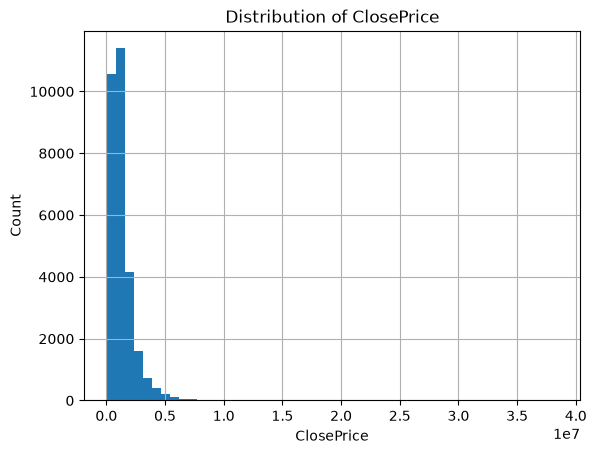

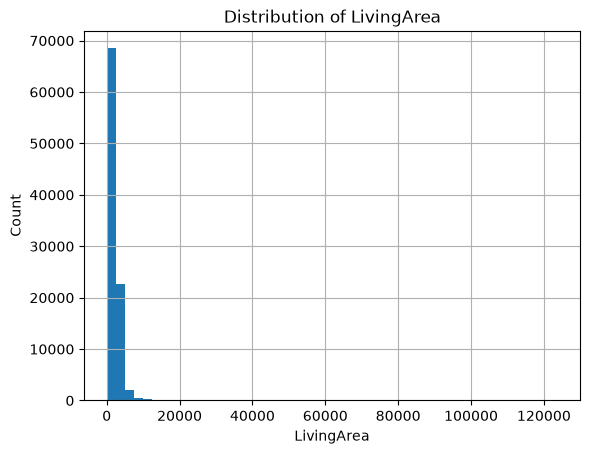

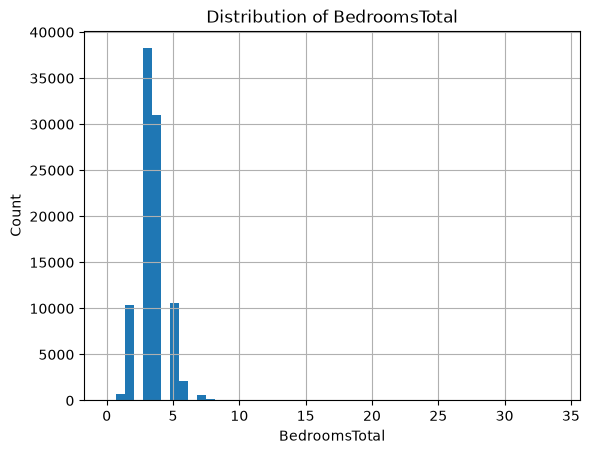

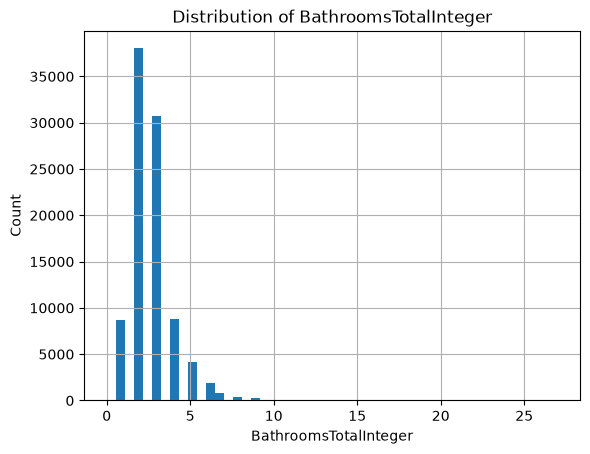

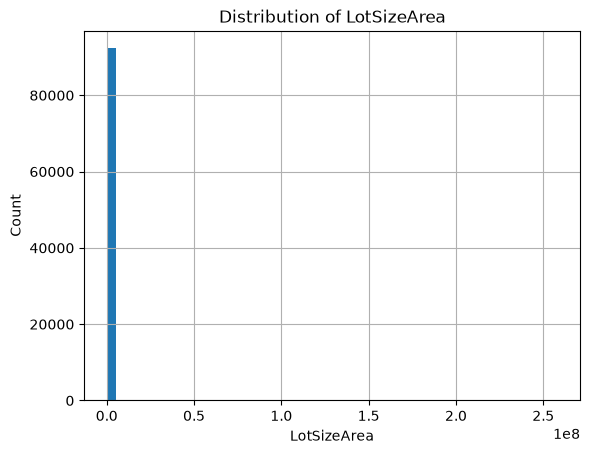

In [21]:
for col in cols:
    df_res[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

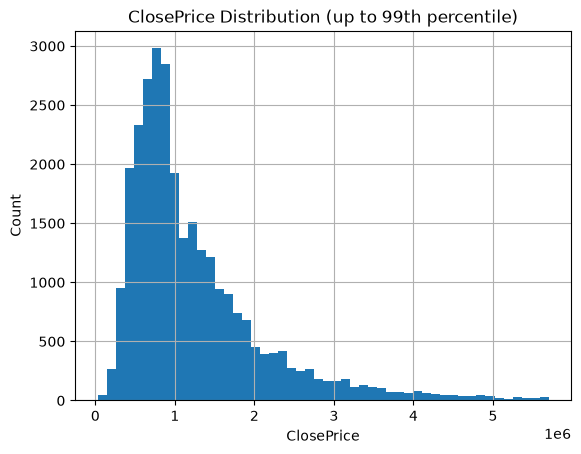

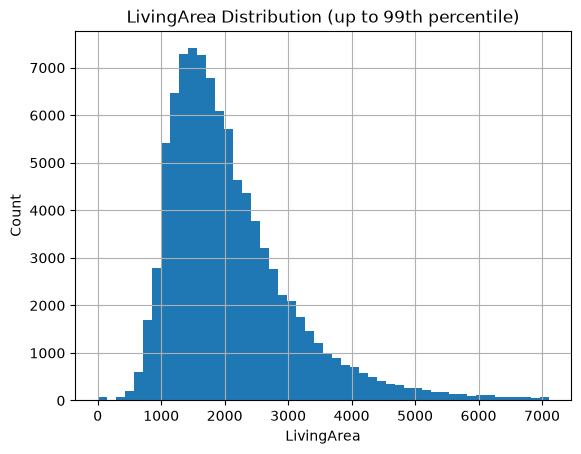

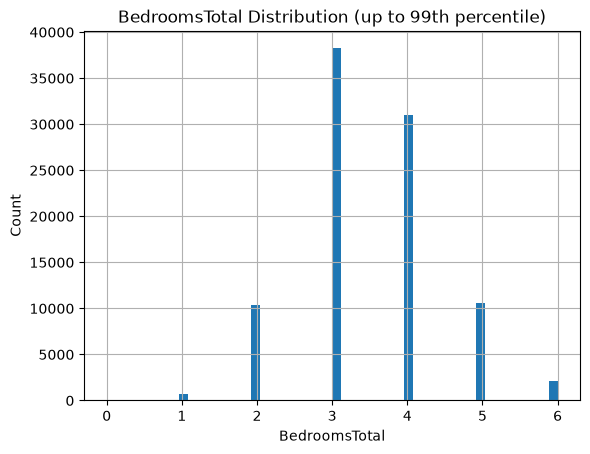

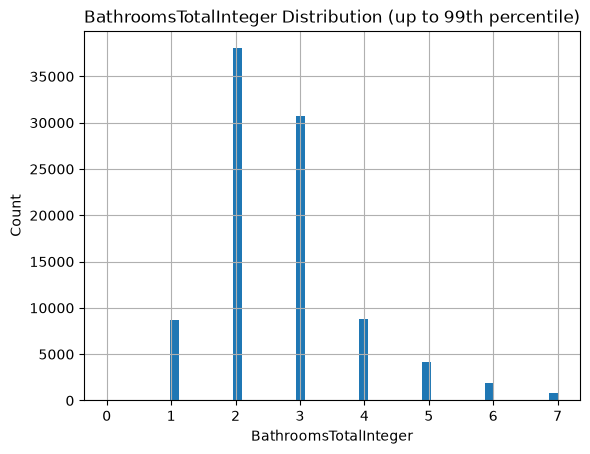

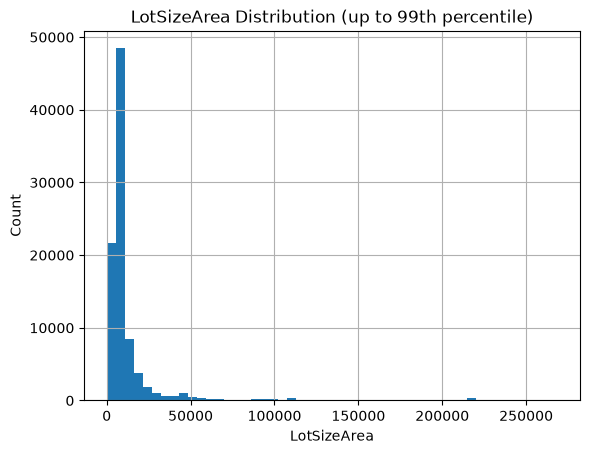

In [22]:
for col in cols:
    upper = df_res[col].quantile(0.99)
    trimmed = df_res[df_res[col] <= upper]

    trimmed[col].hist(bins=50)
    plt.title(f"{col} Distribution (up to 99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

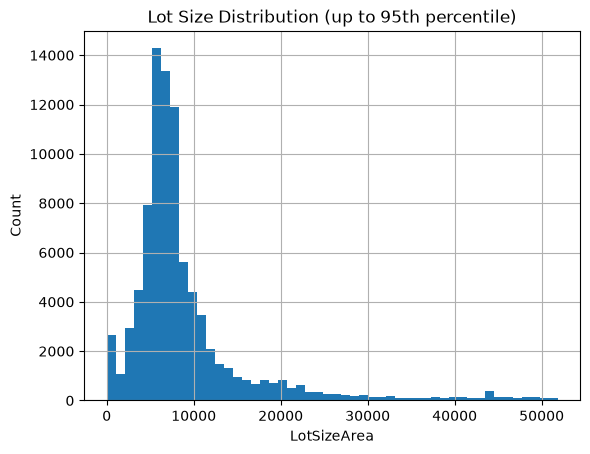

In [25]:
lot_upper = df_res["LotSizeArea"].quantile(0.95)

df_res.loc[
    (df_res["LotSizeArea"] > 0) &
    (df_res["LotSizeArea"] <= lot_upper),
    "LotSizeArea"
].hist(bins=50)

plt.title("Lot Size Distribution (up to 95th percentile)")
plt.xlabel("LotSizeArea")
plt.ylabel("Count")
plt.show()